# Per-Finger Touch Detection Model (LSTM in PyTorch)

This notebook builds and trains an **LSTM model** for per-finger touch detection using transition velocities.

## 1. Imports & Hyperparameters Setup

In [73]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Hyperparameters
SEQ_LEN = 4          # 4 velocity transition steps
FEATURE_DIM = 8      # 2 wrist vels + 6 finger joint vels
BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_UNITS = 32     # Baseline hidden units
DROPOUT = 0.5         # Baseline dropout
EPOCHS = 40

# Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load & Prepare CSV Datasets (`training_data.csv` & `test_data.csv`)

In [74]:
def extract_features_and_labels(csv_path):
    df = pd.read_csv(csv_path)
    
    vel_cols_step = []
    for v in range(1, 5):
        cols = [
            f"wrist{v}_vx", f"wrist{v}_vy",
            f"mcp{v}_vx", f"mcp{v}_vy",
            f"pip{v}_vx", f"pip{v}_vy",
            f"dip{v}_vx", f"dip{v}_vy"
        ]
        vel_cols_step.append(cols)
        
    n_samples = len(df)
    X = np.zeros((n_samples, 4, 8), dtype=np.float32)
    
    for step_idx in range(4):
        cols = vel_cols_step[step_idx]
        X[:, step_idx, :] = df[cols].fillna(0.0).values.astype(np.float32)
        
    target_col = "touch_finger" if "touch_finger" in df.columns else "touch"
    y = df[target_col].astype(str).str.strip().str.lower().isin(["1", "true", "t", "yes", "y"]).values.astype(np.float32)
    y = y.reshape(-1, 1)
    
    return X, y

TRAIN_CSV = "./data/training_data.csv"
TEST_CSV = "./data/test_data.csv"

X_train_np, y_train_np = extract_features_and_labels(TRAIN_CSV)
X_test_np, y_test_np = extract_features_and_labels(TEST_CSV)

X_train = torch.from_numpy(X_train_np).type(torch.float32)
y_train = torch.from_numpy(y_train_np).type(torch.float32)
X_test = torch.from_numpy(X_test_np).type(torch.float32)
y_test = torch.from_numpy(y_test_np).type(torch.float32)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape: torch.Size([3206, 4, 8]), y_train shape: torch.Size([3206, 1])
X_test shape:  torch.Size([486, 4, 8]),  y_test shape:  torch.Size([486, 1])


## 3. PyTorch Dataset and DataLoader

In [75]:
class VelocitySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = VelocitySequenceDataset(X_train, y_train)
test_dataset = VelocitySequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. Building the LSTM Touch Detection Model

In [76]:
class FingerTouchLSTM(nn.Module):
    def __init__(self, input_features: int = 8, hidden_units: int = 32, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=hidden_units,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Linear(in_features=hidden_units, out_features=16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(in_features=16, out_features=1)
        )
        
    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        last_timestep = lstm_out[:, -1, :]
        logits = self.classifier(last_timestep)
        return logits

model_0 = FingerTouchLSTM(input_features=FEATURE_DIM, hidden_units=HIDDEN_UNITS, num_layers=2, dropout=DROPOUT).to(device)
print(model_0)

FingerTouchLSTM(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.5)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Loss Function, Optimizer, and Accuracy Function

In [77]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=LEARNING_RATE)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 6. Training and Testing Loop

In [78]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    model_0.train()
    train_loss, train_acc = 0.0, 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_logits = model_0(X_batch)
        loss = loss_fn(y_logits, y_batch)
        y_preds = torch.round(torch.sigmoid(y_logits))
        acc = accuracy_fn(y_batch, y_preds)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(X_batch)
        train_acc += (acc / 100.0) * len(X_batch)
        
    train_loss /= len(train_dataset)
    train_acc = (train_acc / len(train_dataset)) * 100
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # --- Testing Phase ---
    model_0.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            test_logits = model_0(X_batch)
            t_loss = loss_fn(test_logits, y_batch)
            test_preds = torch.round(torch.sigmoid(test_logits))
            t_acc = accuracy_fn(y_batch, test_preds)
            
            test_loss += t_loss.item() * len(X_batch)
            test_acc += (t_acc / 100.0) * len(X_batch)
            
        test_loss /= len(test_dataset)
        test_acc = (test_acc / len(test_dataset)) * 100
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 01 | Train Loss: 0.6410 | Train Acc: 64.75% | Test Loss: 0.5284 | Test Acc: 75.51%
Epoch: 05 | Train Loss: 0.3412 | Train Acc: 88.12% | Test Loss: 0.3706 | Test Acc: 86.01%
Epoch: 10 | Train Loss: 0.3105 | Train Acc: 88.90% | Test Loss: 0.3175 | Test Acc: 86.01%
Epoch: 15 | Train Loss: 0.2897 | Train Acc: 89.11% | Test Loss: 0.3361 | Test Acc: 85.39%
Epoch: 20 | Train Loss: 0.2728 | Train Acc: 89.61% | Test Loss: 0.3305 | Test Acc: 85.60%
Epoch: 25 | Train Loss: 0.2616 | Train Acc: 89.68% | Test Loss: 0.3302 | Test Acc: 85.19%
Epoch: 30 | Train Loss: 0.2713 | Train Acc: 89.39% | Test Loss: 0.3321 | Test Acc: 85.60%
Epoch: 35 | Train Loss: 0.2694 | Train Acc: 89.89% | Test Loss: 0.3280 | Test Acc: 86.21%
Epoch: 40 | Train Loss: 0.2624 | Train Acc: 89.80% | Test Loss: 0.3026 | Test Acc: 85.80%


## 7. Plotting Training and Testing Curves

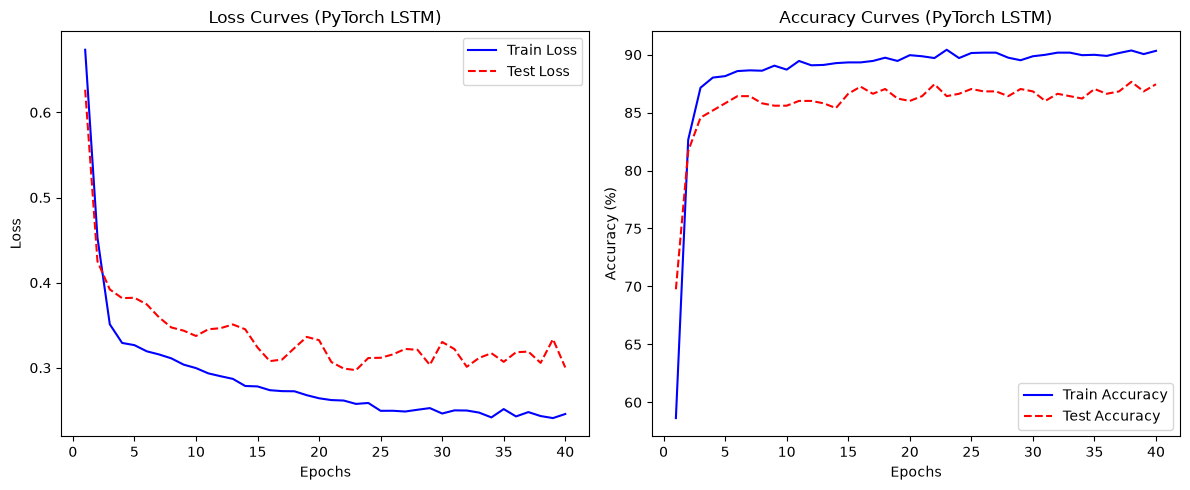

In [72]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", color="blue")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss", color="red", linestyle="--")
plt.title("Loss Curves (PyTorch LSTM)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label="Train Accuracy", color="blue")
plt.plot(range(1, EPOCHS + 1), test_accuracies, label="Test Accuracy", color="red", linestyle="--")
plt.title("Accuracy Curves (PyTorch LSTM)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

## 8. Evaluation: Heatmap & Text Confusion Matrix & Classification Report


 CONFUSION MATRIX (FingerTouchLSTM)
[[323  81]
 [ 18 305]]

Classification Report:
               precision    recall  f1-score   support

 Untouch (0)       0.95      0.80      0.87       404
   Touch (1)       0.79      0.94      0.86       323

    accuracy                           0.86       727
   macro avg       0.87      0.87      0.86       727
weighted avg       0.88      0.86      0.86       727



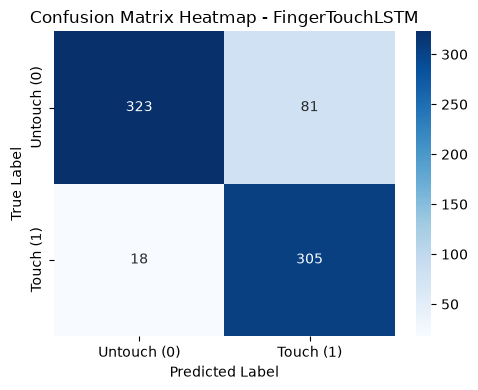

In [31]:
model_0.eval()
all_preds, all_targets = [], []
with torch.inference_mode():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        logits = model_0(X_b)
        preds = torch.round(torch.sigmoid(logits)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_b.numpy())

all_preds = np.array(all_preds).squeeze()
all_targets = np.array(all_targets).squeeze()

cm = confusion_matrix(all_targets, all_preds)
labels = ["Untouch (0)", "Touch (1)"]

# Printed Text Analytics
print("\n" + "="*50)
print(" CONFUSION MATRIX (FingerTouchLSTM)")
print("="*50)
print(cm)
print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=labels))
print("="*50)

# Graphical Plot Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Heatmap - FingerTouchLSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 9. Saving Model Weights

In [9]:
MODEL_SAVE_PATH = "finger_touch_lstm.pth"
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved successfully to: {MODEL_SAVE_PATH}")